# What's the correct flux to report for SBND?

In [2]:
%load_ext autoreload
%autoreload 2



In [3]:
import os
import sys
from pathlib import Path

import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import uproot
from tqdm import tqdm

## Compare different compressions of flux

- **Nominal** — `sbnd_original_flux.root` (collaboration histogram).
- **dk2nu** — same beam dk2nu file as flux simulation; νμ from `decay.ntype == 14`; all `nuray` entries with their weights (weights sum to ~1 per dk2nu entry).
- **Path-length weighted** — same rays, histogram weights `wgt × path length` through a nominal SBND active box in dk2nu beam coordinates (see dkmeta `location` for SBND).

Absolute normalization of raw dk2nu weights to `/m²/10⁶ POT` needs the beam simulation / area prescription used to build the nominal file. Here we **rescale dk2nu-derived histograms to match the nominal integral** (0–3 GeV) and show **shape ratios** for closure.

∫φ dE (nominal, per cm² per POT): 1.615e-08


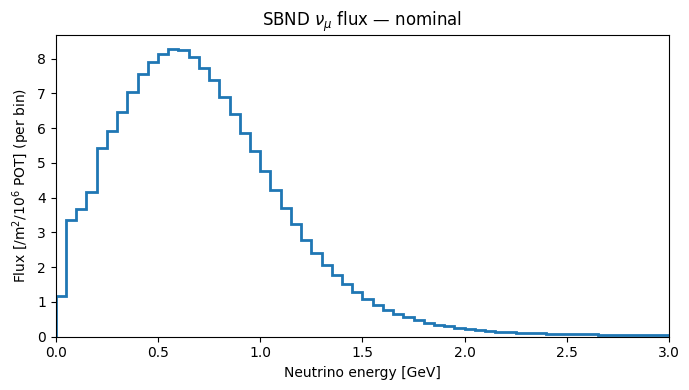

In [89]:
# Nominal SBND νμ flux (analysis / constants use this file)
FLUXFILE = "/exp/sbnd/data/users/munjung/flux/sbnd_original_flux.root"
FLUXFILE_DK2NU = "/exp/sbnd/data/users/munjung/xsec/flux_closure/sbnd_dk2nu_hist.root"

fig, ax = plt.subplots(figsize=(7, 4))

flux = uproot.open(FLUXFILE)
numu_flux = flux["flux_sbnd_numu"].to_numpy()
bin_edges = numu_flux[1]
flux_vals = numu_flux[0]
ax.hist(bin_edges[:-1], bins=bin_edges, weights=flux_vals, histtype="step", linewidth=2, color="C0")

# flux = uproot.open(FLUXFILE_DK2NU)
# numu_flux = flux["flux_sbnd_numu"].to_numpy()
# bin_edges = numu_flux[1]
# flux_vals = numu_flux[0]
# ax.hist(bin_edges[:-1], bins=bin_edges, weights=flux_vals, histtype="step", linewidth=2, color="C1")

ax.set_xlim(0, 3)
ax.set_xlabel("Neutrino energy [GeV]")
ax.set_ylabel("Flux [/m$^{2}$/10$^{6}$ POT] (per bin)")
ax.set_title(r"SBND $\nu_\mu$ flux — nominal")
fig.tight_layout()
fig.savefig("sbnd-flux.pdf", bbox_inches="tight")

# ∫φ dE in file units: sum of bin contents (histogram weights are bin-integrated flux)
integrated_flux_per_cm2_per_pot = flux_vals.sum() / (1e4 * 1e6)
print("∫φ dE (nominal, per cm² per POT): %.3e" % integrated_flux_per_cm2_per_pot)



In [56]:
def load_dk2nu(filename):
    dkf = uproot.open(filename)
    dk_tree = dkf["dk2nuTree"]
    pots = float(dkf["dkmetaTree"]["dkmeta/pots"].array()[0])
    # print("dk2nu simulated POT (dkmeta): %.6g" % pots)

    branches = [
        "dk2nu/decay/decay.ntype",
        "dk2nu/decay/decay.nimpwt",
        "dk2nu/nuray/nuray.E",
        "dk2nu/nuray/nuray.wgt",
    ]
    arrays = dk_tree.arrays(branches, library="ak")
    mask_numu = arrays["dk2nu/decay/decay.ntype"] == 14
    nimpwt = arrays["dk2nu/decay/decay.nimpwt"][mask_numu]
    E_flat = arrays["dk2nu/nuray/nuray.E"][mask_numu] #[:, i]
    w_flat = arrays["dk2nu/nuray/nuray.wgt"][mask_numu] #[:, i]

    dkf.close()

    return {"E_flat": np.array(E_flat), "w_flat": np.array(w_flat), "nimpwt": np.array(nimpwt)}


In [49]:
DK2NU_DIR =  "/cvmfs/sbnd.osgstorage.org/pnfs/fnal.gov/usr/sbnd/persistent/stash/fluxFiles/bnb/G4BNB/v1.1.1/fhc/a"
dk2nu_files = os.listdir(DK2NU_DIR)

this_filename = os.path.join(DK2NU_DIR, dk2nu_files[0])
dkf = uproot.open(this_filename)
dk_tree = dkf["dkmetaTree"] #["dk2nuTree"]
dk_tree.keys()

branches = ["dkmeta/location/location.x", "dkmeta/location/location.y", "dkmeta/location/location.z", "dkmeta/location/location.name"]
arrays = dk_tree.arrays(branches, library="ak")
name = arrays["dkmeta/location/location.name"]
x = arrays["dkmeta/location/location.x"]
y = arrays["dkmeta/location/location.y"]
z = arrays["dkmeta/location/location.z"]

idx = -1
print(list(name)[0][idx])
det_x = list(x)[0][idx]
det_y = list(y)[0][idx]
det_z = list(z)[0][idx]
print(det_x, det_y, det_z)

SBND
73.78 0.0 11000.0


In [113]:
import pickle

with open("/exp/sbnd/data/users/munjung/xsec/flux_closure/sbnd_dk2nu_arrays.pkl", "rb") as f:
    data = pickle.load(f)

E_flat_arr = data["E_flat_arr"][:, -1]
w_flat_arr = data["w_flat_arr"][:, -1]
px_arr = data["px_arr"][:, -1]
py_arr = data["py_arr"][:, -1]
pz_arr = data["pz_arr"][:, -1]
vx_arr = data["vx_arr"]
vy_arr = data["vy_arr"]
vz_arr = data["vz_arr"]
nimpwt_arr = data["nimpwt_arr"]

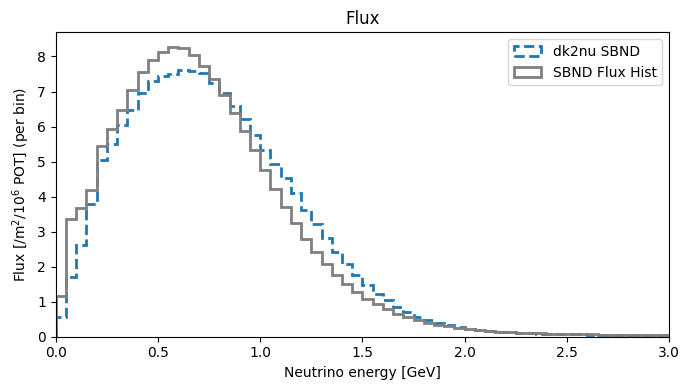

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

for i in [-1]:
    E_flat = E_flat_arr[:, i]
    w_flat = w_flat_arr[:, i]
    nimpwt = nimpwt_arr
    h_dk, _ = np.histogram(E_flat, bins=bin_edges, weights=w_flat * nimpwt)
    scale_int = flux_vals.sum() / np.sum(h_dk)
    h_dk_scaled = h_dk * scale_int
    ax.hist(bin_edges[:-1], bins=bin_edges, weights=h_dk_scaled, histtype="step", linewidth=2, linestyle="--", label="dk2nu " + list(name)[0][i])

ax.hist(bin_edges[:-1], bins=bin_edges, weights=flux_vals, histtype="step", linewidth=2, color="gray", label="SBND Flux Hist")

ax.set_xlim(0, 3)
ax.set_xlabel("Neutrino energy [GeV]")
ax.set_ylabel("Flux [/m$^{2}$/10$^{6}$ POT] (per bin)")
ax.set_title(r"Flux")
ax.legend(loc="upper right")
fig.tight_layout()

output_root_filename = "/exp/sbnd/data/users/munjung/xsec/flux_closure/sbnd_dk2nu_hist.root"
hist_name = "flux_sbnd_numu"
hist_title = "dk2nu Flux Histogram"
n_bins = len(bin_edges) - 1
bin_edges_arr = np.array(bin_edges, dtype=np.float32)
flux_values_arr = h_dk_scaled.astype(np.float32)

with uproot.recreate(output_root_filename) as froot:
    h_export = hist.Hist.new.Variable(bin_edges, name="E", label="Neutrino energy [GeV]").Weight()
    h_export.fill(E=bin_edges[:-1], weight=flux_values_arr)
    froot[hist_name] = h_export.to_numpy()

In [68]:
nuE = E_flat_arr[:, -1]
weights = w_flat_arr[:, -1]
nimpwt = nimpwt_arr

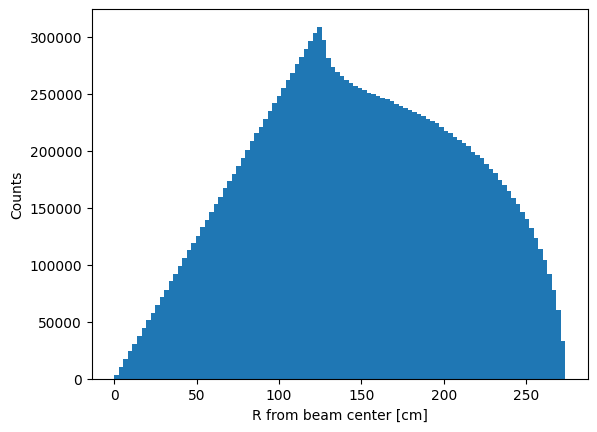

In [111]:
# anyways, follow what John laid out

n_rays = len(nuE)
g4bnb_R = 200 # G4BNB radius

# Repeatedly resample out-of-bounds points until all (x, y) are within the radius
x_rand = np.random.uniform(-g4bnb_R, g4bnb_R, n_rays)
y_rand = np.random.uniform(-g4bnb_R, g4bnb_R, n_rays)
r = np.sqrt(x_rand**2 + y_rand**2)

while np.any(r >= g4bnb_R):
    mask = r >= g4bnb_R
    x_rand[mask] = np.random.uniform(-g4bnb_R, g4bnb_R, np.sum(mask))
    y_rand[mask] = np.random.uniform(-g4bnb_R, g4bnb_R, np.sum(mask))
    r[mask] = np.sqrt(x_rand[mask]**2 + y_rand[mask]**2)


# r = np.sqrt(x_rand**2 + y_rand**2)
# plt.hist(r, bins=100)
# plt.xlabel("R from coord. center [cm]")
# plt.ylabel("Counts")
# plt.show()

posx = x_rand - det_x
posy = y_rand - det_y

r = np.sqrt(posx**2 + posy**2)
plt.hist(r, bins=100)
plt.xlabel("R from beam center [cm]")
plt.ylabel("Counts")
plt.show()


theta = np.arctan2(np.sqrt((posx - det_x)**2 + (posy - det_y)**2), det_z) * 180 / np.pi


# # divide into PRISM bins
# prism_thetas = np.linspace(0, 1.6, 9) # in degrees
# bins=np.linspace(0, 3, 100)
# print("PRISM bins: ", prism_thetas)
# for th_idx in range(len(prism_thetas)-1):
#     mask = (theta > prism_thetas[th_idx]) & (theta < prism_thetas[th_idx+1])
#     var = nuE[mask]
#     wgts = weights[mask] * nimpwt[mask]
#     plt.hist(var, bins=bins, histtype="step", weights=wgts, density=True, label=f"{prism_thetas[th_idx]:.2f}-{prism_thetas[th_idx+1]:.2f} deg")
# plt.hist(nuE, bins=bins, histtype="step", weights=weights*nimpwt, density=True, label="all")
# plt.xlabel("E [GeV]")
# plt.ylabel("Counts")
# plt.legend()
# plt.show()


In [107]:
def intersect_line_box(origin, direction, box_min, box_max):
    """
    Finds the intersection points of a line with a 3D AABB.
    
    :param origin: (x, y, z) start position
    :param direction: (dx, dy, dz) direction vector
    :param box_min: (x, y, z) coordinates of the box's lower corner
    :param box_max: (x, y, z) coordinates of the box's upper corner
    :return: (point_near, point_far) or None if no intersection
    """
    origin = np.array(origin, dtype=float)
    direction = np.array(direction, dtype=float)
    box_min = np.array(box_min, dtype=float)
    box_max = np.array(box_max, dtype=float)

    # Avoid division by zero for lines parallel to axes
    # We use a small epsilon or handle it via numpy's inf
    inv_dir = 1.0 / direction

    # Calculate t-distances to the planes of the box
    t1 = (box_min - origin) * inv_dir
    t2 = (box_max - origin) * inv_dir

    # t_min and t_max for each axis
    t_entry = np.minimum(t1, t2)
    t_exit = np.maximum(t1, t2)

    # The actual entry/exit points for the 3D box
    t_near = np.max(t_entry)
    t_far = np.min(t_exit)

    # If t_near > t_far, the line misses the box
    if t_near > t_far:
        return None

    # Calculate the 3D coordinates using P = O + tD
    point_near = origin + t_near * direction
    point_far = origin + t_far * direction
    distance = np.linalg.norm(point_near - point_far)

    # print(f"Intersection 1 (Entry): {point_near}")
    # print(f"Intersection 2 (Exit):  {point_far}")
    # print(f"Distance: {distance}")

    return point_near, point_far, distance


In [101]:
p = np.sqrt(px_arr**2 + py_arr**2 + pz_arr**2)
dirx = px_arr / p
diry = py_arr / p
dirz = pz_arr / p
dirx

array([0.01431618, 0.01193327, 0.00900642, ..., 0.00741029, 0.01268491,
       0.00672403], shape=(18152230,))

In [108]:
idx = 0
dists = []
start_points = []
end_points = []
for idx in tqdm(range(len(px_arr))):
    line_origin = [vx_arr[idx], vy_arr[idx], vz_arr[idx]]
    line_dir = [dirx[idx], diry[idx], dirz[idx]]
    min_corner = [det_x - 200, det_y - 200, 11000]
    max_corner = [det_x + 200, det_y + 200, 11000 + 500]
    point_near, point_far, distance = intersect_line_box(line_origin, line_dir, min_corner, max_corner)
    dists.append(distance)
    start_points.append(point_near)
    end_points.append(point_far)

  0%|          | 0/18152230 [00:00<?, ?it/s]

100%|██████████| 18152230/18152230 [06:17<00:00, 48141.83it/s]


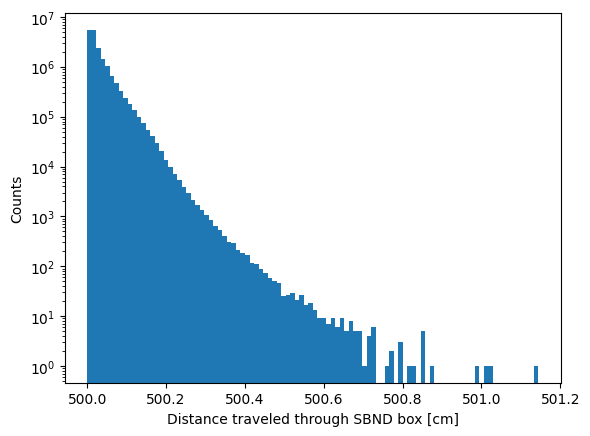

In [105]:
var = plt.hist(dists, bins=100)
plt.xlabel("Distance traveled through SBND box [cm]")
plt.ylabel("Counts")
plt.yscale("log")
plt.show();

In [ ]:
FLUXFILE_DK2NU = "/exp/sbnd/data/users/munjung/xsec/flux_closure/sbnd_dk2nu_hist.root"

fig, ax = plt.subplots(figsize=(7, 4))

flux = uproot.open(FLUXFILE_DK2NU)
numu_flux = flux["flux_sbnd_numu"].to_numpy()
bin_edges = numu_flux[1]
flux_vals = numu_flux[0]
ax.hist(bin_edges[:-1], bins=bin_edges, weights=flux_vals, histtype="step", linewidth=2, color="C0")


ax.set_xlim(0, 3)
ax.set_xlabel("Neutrino energy [GeV]")
ax.set_ylabel("Flux [/m$^{2}$/10$^{6}$ POT] (per bin)")
ax.set_title(r"SBND $\nu_\mu$ flux — nominal")
fig.tight_layout()
fig.savefig("sbnd-flux.pdf", bbox_inches="tight")

# ∫φ dE in file units: sum of bin contents (histogram weights are bin-integrated flux)
integrated_flux_per_cm2_per_pot = flux_vals.sum() / (1e4 * 1e6)
print("∫φ dE (nominal, per cm² per POT): %.3e" % integrated_flux_per_cm2_per_pot)



In [114]:
i = -2 # SBND
print(list(name)[0][i])
E_flat = E_flat_arr[:, i]
w_flat = w_flat_arr[:, i]
nimpwt = nimpwt_arr

# ==== cut based on position at SBND face
# ==== center: (73.78, 0, 11000)
# ==== size (x,y) = (400, 400)

px = px_arr[:, i]
py = py_arr[:, i]
pz = pz_arr[:, i]
p = np.sqrt(px**2 + py**2 + pz**2)

vx = vx_arr
vy = vy_arr
vz = vz_arr

bins = np.linspace(-100, 100, 100)
plt.hist(vx, bins=bins, weights=nimpwt*w_flat, histtype="step")
plt.hist(vy, bins=bins, weights=nimpwt*w_flat, histtype="step")
plt.show();

bins = np.linspace(0, 1000, 100)
plt.hist(vz, bins=bins, weights=nimpwt*w_flat, histtype="step")
plt.show();

posx = px * ((60000 - vz) / pz) + vx
posy = py * ((60000 - vz) / pz) + vy

bins = np.linspace(-200, 200, 100)
plt.hist(posx, bins=bins, weights=nimpwt*w_flat, histtype="step")
plt.hist(posy, bins=bins, weights=nimpwt*w_flat, histtype="step")
plt.show();

T600


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [ ]:
# SBND nominal active box in dk2nu beam coordinates [cm]: full size 400 × 400 × 500, axis-aligned.
SBND_DET_CENTER_CM = np.array([74.0, 0.0, 11000.0])
SBND_DET_HALF_CM = np.array([200.0, 200.0, 250.0])


def ray_aabb_slab_intersection(origin, direction, center, half_extents, normalize=True, forward_only=True, eps=1e-14):
    """Slab method for ray vs axis-aligned box.

    Box: center ``center`` (3,), half-extents ``half_extents`` (3,) so bounds are
    ``center ± half_extents`` on each axis.

    Ray: ``r(t) = origin + t * direction``. If ``normalize`` (default), ``direction`` is
    scaled to unit length and ``t`` is distance in cm.

    Slab recipe: per axis i, planes x_i = c_i ± h_i; form
    [t_near,i, t_far,i] from sorted intersections. Then
    t_enter = max_i t_near,i, t_exit = min_i t_far,i.

    Returns hit, t_enter, t_exit, t_in, t_out, p_enter, p_exit, L.
    """
    o = np.asarray(origin, dtype=np.float64)
    d = np.asarray(direction, dtype=np.float64)
    c = np.asarray(center, dtype=np.float64)
    h = np.asarray(half_extents, dtype=np.float64)
    if o.shape[-1] != 3 or d.shape[-1] != 3:
        raise ValueError("origin and direction last dim must be 3")
    if normalize:
        d = d / (np.linalg.norm(d, axis=-1, keepdims=True) + 1e-20)
    bmin = c - h
    bmax = c + h
    inv_d = np.where(np.abs(d) < eps, np.sign(d + eps) * np.inf, 1.0 / d)
    t0 = (bmin - o) * inv_d
    t1 = (bmax - o) * inv_d
    t_near = np.minimum(t0, t1)
    t_far = np.maximum(t0, t1)
    t_enter = np.max(t_near, axis=-1)
    t_exit = np.min(t_far, axis=-1)
    if forward_only:
        t_in = np.maximum(t_enter, 0.0)
    else:
        t_in = t_enter
    hit = (t_exit > t_in) & (t_exit >= t_enter) & np.isfinite(t_enter) & np.isfinite(t_exit)
    L = np.where(hit, t_exit - t_in, 0.0)
    t_in_b = np.expand_dims(t_in, axis=-1)
    t_exit_b = np.expand_dims(t_exit, axis=-1)
    hit_b = np.expand_dims(hit, axis=-1)
    p_enter = np.where(hit_b, o + t_in_b * d, np.nan)
    p_exit = np.where(hit_b, o + t_exit_b * d, np.nan)
    t_out = t_exit
    return hit, t_enter, t_exit, t_in, t_out, p_enter, p_exit, L


def ray_aabb_path_length_cm(origin, direction, center, half_extents, **kwargs):
    *_, L = ray_aabb_slab_intersection(origin, direction, center, half_extents, **kwargs)
    return L


_o = np.zeros(3)
_d = SBND_DET_CENTER_CM.copy()
hit, te, tx, tin, tout, pe, px, L = ray_aabb_slab_intersection(_o, _d, SBND_DET_CENTER_CM, SBND_DET_HALF_CM)
print("Example ray (0,0,0) toward SBND center direction:", "hit", bool(hit), "L_cm", float(L))
print("  p_enter", pe, "p_exit", px)


IndexError: cannot slice ListOffsetArray (of length 1) with 1

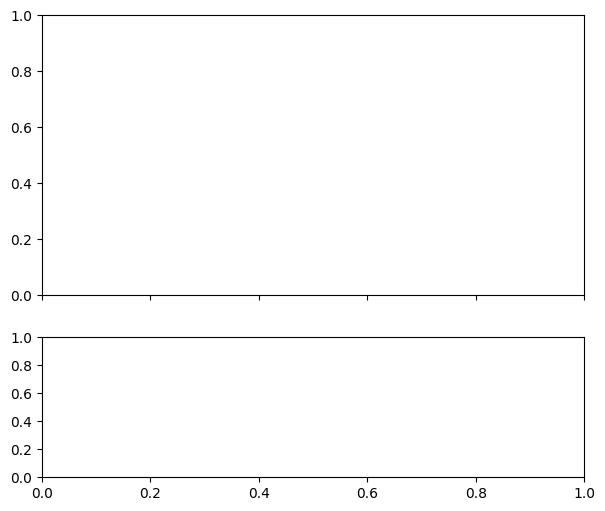

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
ax0, ax1 = axes

ax0.hist(bin_edges[:-1], bins=bin_edges, weights=flux_vals, histtype="step", linewidth=2, color="gray", label="Nominal")

h_dk, _ = np.histogram(E_flat, bins=bin_edges, weights=w_flat * nimpwt)
scale_int = flux_vals.sum() / np.sum(h_dk)
h_dk_scaled = h_dk * scale_int
ax0.hist(bin_edges[:-1], bins=bin_edges, weights=h_dk_scaled, histtype="step", linewidth=2, linestyle="--", label="dk2nu")

ax0.set_ylabel("Flux [/m$^{2}$/10$^{6}$ POT] (per bin)")
ax0.set_xlim(0, 3)
ax0.legend(loc="upper right")
ax0.set_title(r"$\nu_\mu$ flux: nominal vs dk2nu (integral-matched)")

# ratio = np.divide(flux_vals, h_dk_scaled, out=np.ones_like(flux_vals), where=h_dk_scaled > 0)
# ax1.axhline(1.0, color="k", lw=0.8)
# ax1.step(bin_edges[:-1], ratio, where="post", color="C2")
# ax1.set_xlabel("Neutrino energy [GeV]")
# ax1.set_ylabel("Nominal / dk2nu")
# ax1.set_ylim(0.5, 1.5)
fig.tight_layout()
plt.show();



In [ ]:
# Path length through nominal SBND box (dk2nu beam coordinates, cm)
# SBND entry from dkmeta "location" for this file
meta = dkf["dkmetaTree"].arrays(["location.x", "location.y", "location.z", "location.name"], library="ak")
names = ak.to_list(meta["location.name"][0])
ix = names.index("SBND")
cx = float(ak.to_list(meta["location.x"][0])[ix])
cy = float(ak.to_list(meta["location.y"][0])[ix])
cz = float(ak.to_list(meta["location.z"][0])[ix])
# Active volume ~ 380 × 380 × 440 cm³ (same numbers as analysis constants), axis-aligned in beam frame
hx, hy, hz = 190.0, 190.0, 220.0
bmin = np.array([cx - hx, cy - hy, cz - hz])
bmax = np.array([cx + hx, cy + hy, cz + hz])


def ray_aabb_clip_length(o, d):
    """Path length (cm) of ray o + t d, t>=0, inside axis-aligned box [bmin,bmax]. Vectorized."""
    d = np.asarray(d, dtype=np.float64)
    d = d / (np.linalg.norm(d, axis=-1, keepdims=True) + 1e-20)
    o = np.asarray(o, dtype=np.float64)
    inv_d = np.where(np.abs(d) < 1e-14, np.sign(d + 1e-20) * np.inf, 1.0 / d)
    t0 = (bmin - o) * inv_d
    t1 = (bmax - o) * inv_d
    tmin = np.minimum(t0, t1)
    tmax = np.maximum(t0, t1)
    t_enter = np.max(tmin, axis=-1)
    t_exit = np.min(tmax, axis=-1)
    hit = t_exit > np.maximum(t_enter, 0.0)
    return np.where(hit, t_exit - np.maximum(t_enter, 0.0), 0.0)


arrays_full = dk_tree.arrays(
    [
        "dk2nu/decay/decay.ntype",
        "dk2nu/decay/decay.vx",
        "dk2nu/decay/decay.vy",
        "dk2nu/decay/decay.vz",
        "dk2nu/nuray/nuray.px",
        "dk2nu/nuray/nuray.py",
        "dk2nu/nuray/nuray.pz",
        "dk2nu/nuray/nuray.E",
        "dk2nu/nuray/nuray.wgt",
    ],
    library="ak",
)
m = arrays_full["dk2nu/decay/decay.ntype"] == 14
vx = ak.to_numpy(arrays_full["dk2nu/decay/decay.vx"][m])
vy = ak.to_numpy(arrays_full["dk2nu/decay/decay.vy"][m])
vz = ak.to_numpy(arrays_full["dk2nu/decay/decay.vz"][m])
n_per = ak.num(arrays_full["dk2nu/nuray/nuray.E"][m], axis=1)
if not ak.all(n_per == n_per[0]):
    raise RuntimeError("Variable nuray multiplicity — update repeat logic")
nray = int(n_per[0])
vx_r = np.repeat(vx, nray)
vy_r = np.repeat(vy, nray)
vz_r = np.repeat(vz, nray)
o = np.stack([vx_r, vy_r, vz_r], axis=1)
px = ak.to_numpy(ak.flatten(arrays_full["dk2nu/nuray/nuray.px"][m]))
py = ak.to_numpy(ak.flatten(arrays_full["dk2nu/nuray/nuray.py"][m]))
pz = ak.to_numpy(ak.flatten(arrays_full["dk2nu/nuray/nuray.pz"][m]))
d = np.stack([px, py, pz], axis=1)
E_pv = ak.to_numpy(ak.flatten(arrays_full["dk2nu/nuray/nuray.E"][m]))
w_pv = ak.to_numpy(ak.flatten(arrays_full["dk2nu/nuray/nuray.wgt"][m]))
L_cm = ray_aabb_clip_length(o, d)
w_path = w_pv * L_cm
print("Fraction of νμ rays with L>0 in SBND box: %.3f" % np.mean(L_cm > 0))

sel = (bin_edges[:-1] < 3.0) & (bin_edges[1:] <= 3.001)
h_path, _ = np.histogram(E_pv, bins=bin_edges, weights=w_path)
scale_p = flux_vals[sel].sum() / h_path[sel].sum()
h_path_scaled = h_path * scale_p

fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
ax0, ax1 = axes
ax0.hist(bin_edges[:-1], bins=bin_edges, weights=flux_vals, histtype="step", linewidth=2, color="C0", label="Nominal")
ax0.hist(bin_edges[:-1], bins=bin_edges, weights=h_path_scaled, histtype="step", linewidth=2, color="C3", linestyle="--", label="dk2nu × L (scaled ∫)")
ax0.set_ylabel("Arbitrary flux units (per bin)")
ax0.set_xlim(0, 3)
ax0.legend(loc="upper right")
ax0.set_title(r"Nominal vs path-length–weighted dk2nu ($\int w\,L$ in box)")

ratio2 = np.divide(flux_vals, h_path_scaled, out=np.ones_like(flux_vals), where=h_path_scaled > 0)
ax1.axhline(1.0, color="k", lw=0.8)
ax1.step(bin_edges[:-1], ratio2, where="post", color="C2")
ax1.set_xlabel("Neutrino energy [GeV]")
ax1.set_ylabel("Nominal / (w×L)")
ax1.set_ylim(0.5, 1.5)
fig.tight_layout()



## MC truth vs flux models

Load a slice of SBND CAF split data (`mcnu` + `hdr`). True neutrino energy spectra are **flux × σ(E)** (and cuts), not identical to flux shape.

**Cross section unit** (same prescription as `analysis_village/numucc_1p0pi/constants.py`):  
`xsec_unit = 1 / (integrated_flux × N_targets)` with `integrated_flux = POT × ∑φ_bin / (10⁴·10⁶)` [cm⁻²] and `N_targets = ρ V N_A / M_Ar` for active Ar volume.

In [ ]:
# One concat chunk — point to any split `.df` that has `mcnu` + `hdr` + `split`
MC_DF = Path("/exp/sbnd/data/users/munjung/xsec/2025Spring_v10_06_00_09/MC/BNB_cosmics/ab-sel_all-wgts.df")
if not MC_DF.is_file():
    raise FileNotFoundError("Set MC_DF to a local split dataframe with mcnu/hdr")

_nmax = 6  # match split chunks in file
mcnu_df = load_dfs(str(MC_DF), ["mcnu"], n_max_concat=_nmax)["mcnu"]
hdr_df = load_dfs(str(MC_DF), ["hdr"], n_max_concat=_nmax)["hdr"]
mc_tot_pot = hdr_df["pot"].sum()
print("MC POT (this file): %.4e" % mc_tot_pot)

pdg = mcnu_df[("pdg", "", "")]
E_nu = mcnu_df[("E", "", "")]
iscc = mcnu_df[("iscc", "", "")]
pos = mcnu_df[[("position", "x", ""), ("position", "y", ""), ("position", "z", "")]].copy()
pos.columns = ["x", "y", "z"]
in_fv = InFV(pos, det="SBND_nohighyz")

numu_cc = (pdg == 14) & (iscc == 1) & in_fv
print("νμ CC in FV (truth): %d events" % numu_cc.sum())

# Truth 1p0π proxy (same kinematic thresholds as categories.Is_1p0pi minus mu/p containment)
nmu = mcnu_df[("nmu_220MeVc", "", "")]
np300 = mcnu_df[("np_300MeVc", "", "")]
npi70 = mcnu_df[("npi_70MeVc", "", "")]
npi0 = mcnu_df[("npi0", "", "")]
sig_proxy = numu_cc & (nmu == 1) & (np300 == 1) & (npi70 == 0) & (npi0 == 0)
print("νμ CC 1p0π proxy in FV: %d events" % sig_proxy.sum())

# Integrated flux × targets (numucc_1p0pi convention)
V_SBND = 380 * 380 * 440  # cm³
NTARGETS = RHO * V_SBND * N_A / M_AR
int_flux_cm2 = mc_tot_pot * flux_vals.sum() / (1e4 * 1e6)
xsec_unit = 1.0 / (int_flux_cm2 * NTARGETS)
print("N_targets (Ar, active box): %.4e" % NTARGETS)
print("Integrated flux × POT (cm⁻²): %.4e" % int_flux_cm2)
print("xsec_unit ≈ %.4e cm² / n" % xsec_unit)



In [ ]:
def _norm_hist(values, weights, bins):
    h, _ = np.histogram(values, bins=bins, weights=weights)
    return h / h.sum() if h.sum() > 0 else h

# Compare shapes (normalized to unit area in bin space)
h_flux = _norm_hist(bin_edges[:-1], flux_vals, bin_edges)
h_dk_n = _norm_hist(E_flat, w_flat, bin_edges)
h_path_n = _norm_hist(E_pv, w_path, bin_edges)
h_mc_numu = _norm_hist(E_nu[numu_cc], np.ones(numu_cc.sum()), bin_edges)

fig, ax = plt.subplots(figsize=(7, 4))
ax.step(bin_edges[:-1], h_flux, where="post", label="Nominal flux")
ax.step(bin_edges[:-1], h_dk_n, where="post", label="dk2nu (νμ, w)")
ax.step(bin_edges[:-1], h_path_n, where="post", label="dk2nu (w×L)")
ax.step(bin_edges[:-1], h_mc_numu, where="post", label=r"MC truth νμ CC FV ($E_\nu$)")
ax.set_xlim(0, 3)
ax.set_xlabel("Neutrino energy [GeV]")
ax.set_ylabel("Normalized (sum of bins = 1)")
ax.legend(loc="upper right", fontsize=8)
ax.set_title("Shape comparison: flux models vs MC νμ CC (not identical — MC includes σ(E))")
fig.tight_layout()



In [ ]:
h_mc_sig = _norm_hist(E_nu[sig_proxy], np.ones(sig_proxy.sum()), bin_edges)

fig, ax = plt.subplots(figsize=(7, 4))
ax.step(bin_edges[:-1], h_flux, where="post", label="Nominal flux")
ax.step(bin_edges[:-1], h_mc_numu, where="post", label=r"νμ CC FV")
ax.step(bin_edges[:-1], h_mc_sig, where="post", label=r"νμ CC 1p0π proxy FV")
ax.set_xlim(0, 3)
ax.set_xlabel("Neutrino energy [GeV]")
ax.set_ylabel("Normalized")
ax.legend(loc="upper right", fontsize=8)
ax.set_title(r"Flux shape vs MC $E_\nu$ for signal-like topology")
fig.tight_layout()

